# Image Classification Project

**Authors:** 

- Michail Theofanopoulos p3352401
- Kitsakis Georgios p3352406

## Overview

This notebook explores **image classification using deep learning**, comparing multiple 
neural network architectures on two benchmark datasets: **Fashion-MNIST** and **CIFAR-10**.

Starting from a simple MLP baseline, we progressively build more sophisticated models — 
plain CNNs, deeper VGG-style networks, augmentation-based training, and a custom ResNet — 
evaluating how each architectural choice impacts classification accuracy and generalization.


In [1]:
import torch
print(torch.cuda.is_available())

True


In [57]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
import pandas as pd

In [4]:
tf.random.set_seed(42)
np.random.seed(42)

In [5]:
def load_fashion_mnist():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
    # Normalize to [0, 1]
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32")  / 255.0
    # Add channel dim → (N, 28, 28, 1)
    x_train = x_train[..., np.newaxis]
    x_test  = x_test[..., np.newaxis]
    return (x_train, y_train), (x_test, y_test)

# Load Fashion-MNIST dataset
(x_train_fmnist, y_train_fmnist), (x_test_fmnist, y_test_fmnist) = load_fashion_mnist()
print(f"Training images shape: {x_train_fmnist.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training images shape: (60000, 28, 28, 1)


In [6]:
def load_cifar10():
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train = x_train.astype("float32") / 255.0
    x_test  = x_test.astype("float32")  / 255.0
    # Flatten labels from (N,1) → (N,)
    y_train = y_train.flatten()
    y_test  = y_test.flatten()
    return (x_train, y_train), (x_test, y_test)

# Load CIFAR-10 dataset
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = load_cifar10()
print(f"Training images shape: {x_train_cifar.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training images shape: (50000, 32, 32, 3)


In [7]:
# Class names for display
FMNIST_CLASSES = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
                  'Sandal','Shirt','Sneaker','Bag','Ankle boot']
CIFAR_CLASSES  = ['Airplane','Automobile','Bird','Cat','Deer',
                  'Dog','Frog','Horse','Ship','Truck']

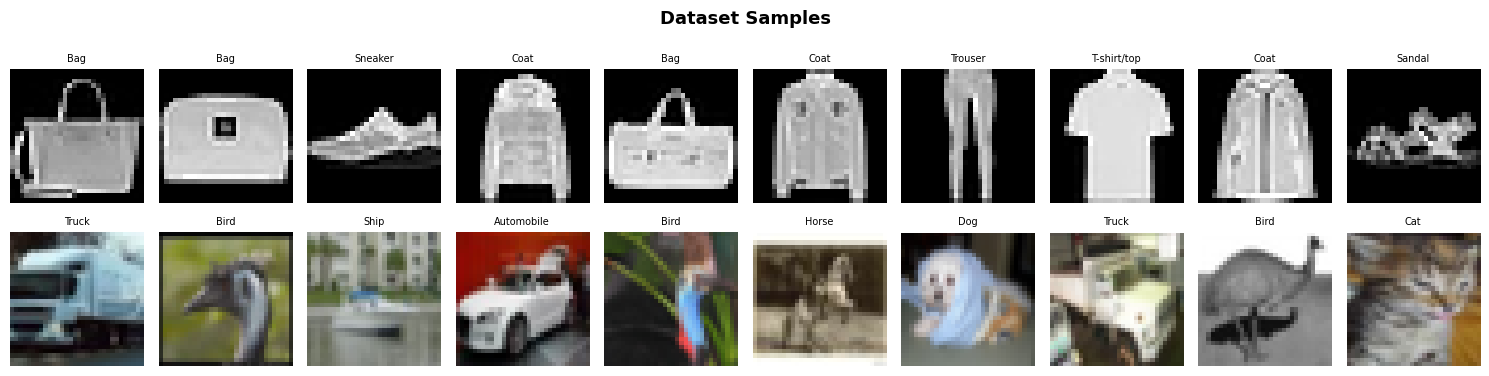

In [8]:
fig, axes = plt.subplots(2, 10, figsize=(15, 4))

# Row 1: Fashion-MNIST
indices_f = np.random.choice(len(x_train_fmnist), 10, replace=False)
for i, ax in enumerate(axes[0]):
    ax.imshow(x_train_fmnist[indices_f[i]], cmap='gray')
    ax.set_title(FMNIST_CLASSES[y_train_fmnist[indices_f[i]]], fontsize=7)
    ax.axis('off')

# Row 2: CIFAR-10
indices_c = np.random.choice(len(x_train_cifar), 10, replace=False)
for i, ax in enumerate(axes[1]):
    ax.imshow(x_train_cifar[indices_c[i]])
    ax.set_title(CIFAR_CLASSES[y_train_cifar[indices_c[i]]], fontsize=7)
    ax.axis('off')

axes[0][0].set_ylabel('Fashion-MNIST', fontsize=10, fontweight='bold')
axes[1][0].set_ylabel('CIFAR-10', fontsize=10, fontweight='bold')

plt.suptitle('Dataset Samples', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
def compile_and_train(model, x_train, y_train, x_test, y_test,
                      epochs=20, batch_size=64, patience=3):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=patience,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            verbose=0
        )
    ]

    history = model.fit(
        x_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.1,
        callbacks=callbacks,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"\n  Test accuracy: {test_acc:.4f}  |  Test loss: {test_loss:.4f}")
    return history, test_acc, test_loss

In [10]:
def show_failed_predictions(model, x_test, y_test, class_names, 
                            model_name, dataset_name, n=10):
    """Show n failed predictions for a given model and dataset."""
    
    # Get predictions
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    
    # Find wrong predictions
    wrong_idx = np.where(y_pred != y_test)[0]
    sample_idx = np.random.choice(wrong_idx, min(n, len(wrong_idx)), replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle(f'Failed Predictions — {model_name} on {dataset_name}', 
                 fontsize=13, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        img = x_test[sample_idx[i]]
        true_label = class_names[y_test[sample_idx[i]]]
        pred_label = class_names[y_pred[sample_idx[i]]]
        
        if img.shape[-1] == 1:
            ax.imshow(img.squeeze(), cmap='gray')
        else:
            ax.imshow(img)
        
        ax.set_title(f'True: {true_label}\nPred: {pred_label}', 
                     fontsize=8, color='red')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

In [11]:
results = []

## 1. Simple MLP Model - Implementation & Testing

### Architecture

A **Multi-Layer Perceptron (MLP)** is a fully-connected feedforward network. Since it operates on flat vectors, the input image is first flattened into a 1D array before being passed through the network.

**Layers:**
- `Flatten` — converts the 2D image (28×28 or 32×32×3) into a 1D vector
- `Dense(512)` → `BatchNormalization` → `Dropout(0.3)`
- `Dense(256)` → `BatchNormalization` → `Dropout(0.3)`
- `Dense(128)` → `Dropout(0.2)`
- `Dense(10, activation='softmax')` — output layer for 10 classes

**BatchNormalization** stabilizes training by normalizing layer inputs.
**Dropout** reduces overfitting by randomly deactivating neurons during training.

### Training

- **Optimizer:** Adam (lr = 1e-3)
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 20, **Batch size:** 64
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping`

### Limitations

MLPs treat each pixel independently and **ignore spatial structure**. This makes them less suited for complex image datasets like CIFAR-10, where local patterns (edges, textures) are critical. As expected, the MLP achieves strong results on Fashion-MNIST but struggles significantly on CIFAR-10.

In [12]:
def build_mlp(input_shape, num_classes=10):
    """
    Simple fully-connected network.
    Flattens the image, then passes through Dense layers.
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax'),
    ], name='MLP')
    return model

In [13]:
model = build_mlp(x_train_fmnist.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_fmnist, y_train_fmnist, 
    x_test_fmnist, y_test_fmnist, epochs=20, patience=15)

<Sequential name=MLP, built=True>
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7493 - loss: 0.7108 - val_accuracy: 0.8360 - val_loss: 0.4434 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8325 - loss: 0.4652 - val_accuracy: 0.8542 - val_loss: 0.3979 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8455 - loss: 0.4227 - val_accuracy: 0.8568 - val_loss: 0.3810 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8529 - loss: 0.4025 - val_accuracy: 0.8705 - val_loss: 0.3497 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8592 - loss: 0.3864 - val_accuracy: 0.8690 - val_loss: 0.3593 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8658 - loss: 0.3697 - val_accuracy: 0.8678 - val_loss: 0.3563 - learning_rate: 0.0010
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step -

In [14]:
results.append({
    'model':    model.name,
    'dataset':  'Fashion-MNIST',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

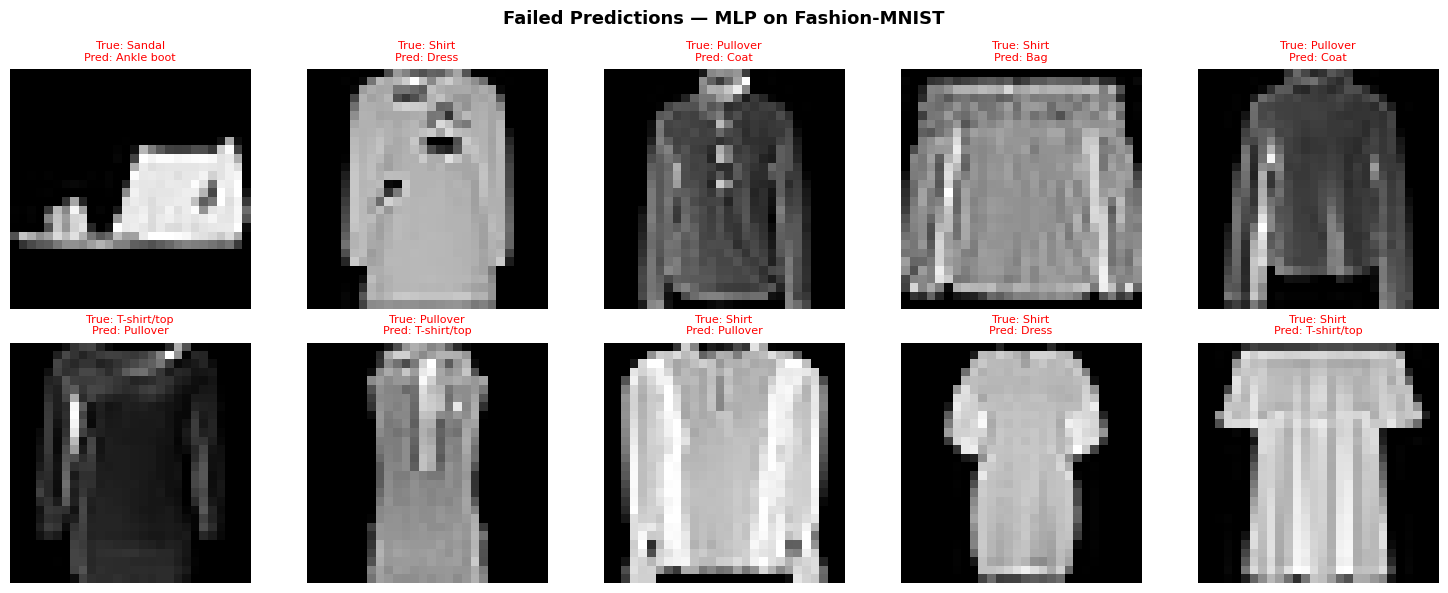

In [15]:
show_failed_predictions(
    model, x_test_fmnist, y_test_fmnist,
    FMNIST_CLASSES, model.name, 'Fashion-MNIST'
)

In [16]:
model = build_mlp(x_train_cifar.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_cifar, y_train_cifar, 
    x_test_cifar, y_test_cifar, epochs=20, patience=15)

<Sequential name=MLP, built=True>
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.2709 - loss: 2.1374 - val_accuracy: 0.3336 - val_loss: 1.8952 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3707 - loss: 1.7563 - val_accuracy: 0.3960 - val_loss: 1.6993 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3907 - loss: 1.7049 - val_accuracy: 0.4390 - val_loss: 1.6016 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4023 - loss: 1.6704 - val_accuracy: 0.4076 - val_loss: 1.6962 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4131 - loss: 1.6391 - val_accuracy: 0.4186 - val_loss: 1.6224 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4125 - loss: 1.6307 - val_accuracy: 0.4440 - val_loss: 1.5426 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step -

In [17]:
results.append({
    'model':    model.name,
    'dataset':  'CIFAR-10',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

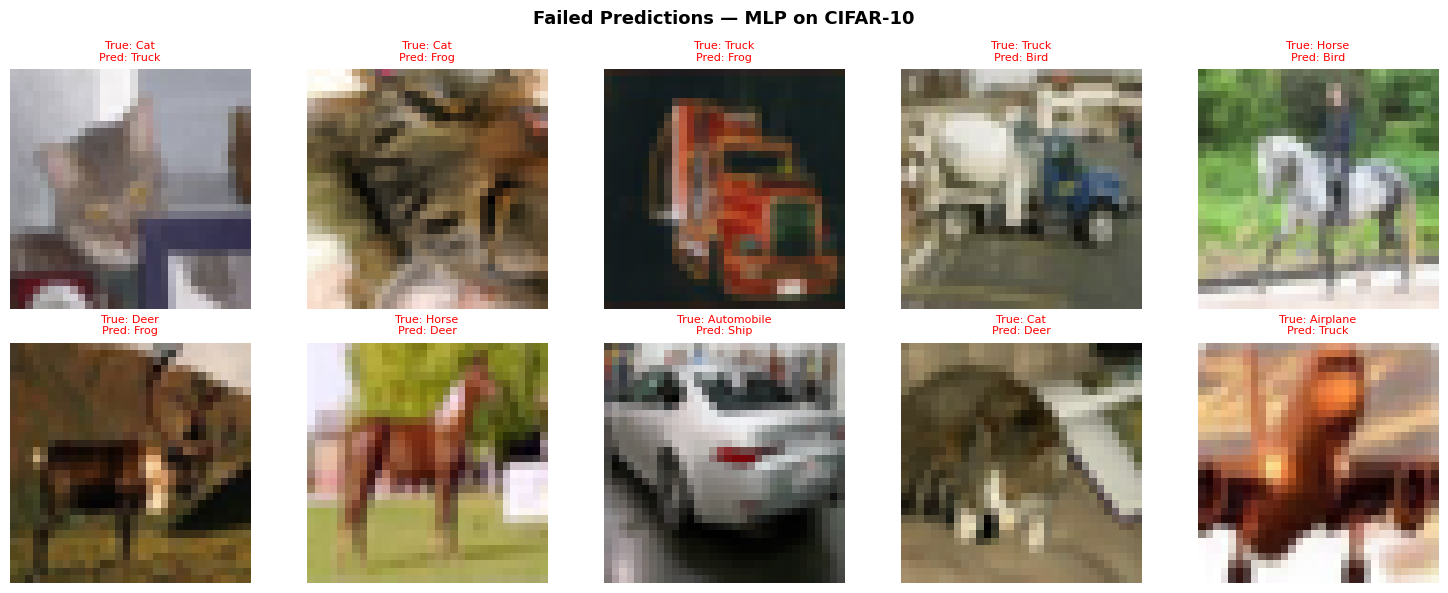

In [18]:
show_failed_predictions(
    model, x_test_cifar, y_test_cifar,
    CIFAR_CLASSES, model.name, 'CIFAR-10'
)

## 2. Simple CNN Model - Implementation & Testing

### Architecture

A **Convolutional Neural Netowork (CNN)** learns spatial hierarchies of features by applying learnable filters across the image. Unlike MLPs, CNNs preserve and exploit the 2D structure of images, making them far more effective for image classification.

**Layers:**
- `Conv2D(32, 3×3)` → `ReLU` → `MaxPooling2D`
- `Conv2D(64, 3×3)` → `ReLU` → `MaxPooling2D`
- `Flatten`
- `Dense(128)` → `Dropout(0.4)`
- `Dense(10, activation='softmax')` — output layer for 10 classes

**Conv2D** extracts local patterns (edges, corners, textures) by sliding filters over the image.
**MaxPooling** down-samples the feature maps, reducing spatial size and adding translation invariance.
The filter count doubles (32 -> 64) so that deeper layers can capture increasingly complex features.

### Training

- **Optimizer:** Adam (lr = 1e-3)
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 20, **Batch size:** 64
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping`

### Improvement over MLP

By capturing local spatial patterns, the Simple CNN significantly outperforms the mlp on both datasets. The improvement is especially pronounced on CIFAR-10, where spatial strcuture in the images (e.g. object shapes and textures) carries most of the discriminative information.

In [19]:
def build_simple_cnn(input_shape, num_classes=10):
    """
    Two conv blocks followed by Dense layers.
    Good balance of simplicity and performance.
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        # Classifier head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Simple_CNN')
    return model

In [20]:
model = build_simple_cnn(x_train_fmnist.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_fmnist, y_train_fmnist, 
    x_test_fmnist, y_test_fmnist, epochs=20, patience=15)

<Sequential name=Simple_CNN, built=True>
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.7402 - loss: 0.7309 - val_accuracy: 0.8710 - val_loss: 0.3490 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8716 - loss: 0.3571 - val_accuracy: 0.8950 - val_loss: 0.2871 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8920 - loss: 0.2989 - val_accuracy: 0.9033 - val_loss: 0.2556 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9060 - loss: 0.2612 - val_accuracy: 0.9087 - val_loss: 0.2462 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9140 - loss: 0.2350 - val_accuracy: 0.9132 - val_loss: 0.2372 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9209 - loss: 0.2137 - val_accuracy: 0.9177 - val_loss: 0.2275 - learning_rate: 0.0010
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms

In [21]:
results.append({
    'model':    model.name,
    'dataset':  'Fashion-MNIST',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

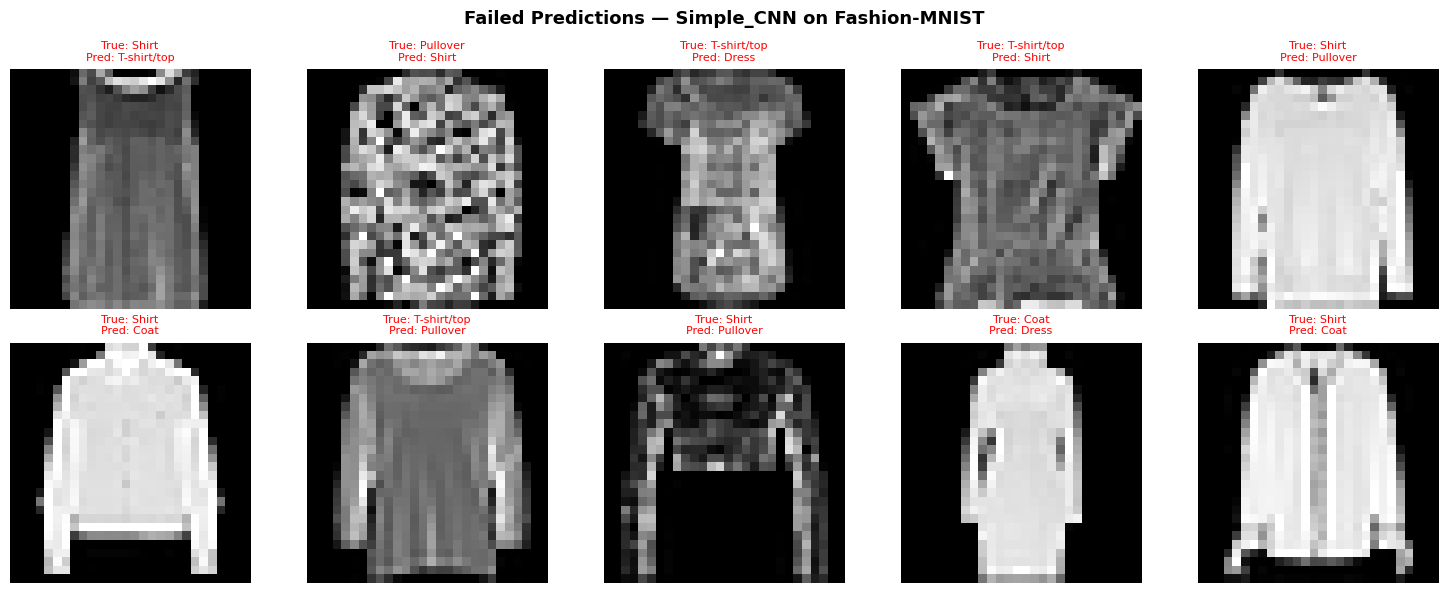

In [22]:
show_failed_predictions(
    model, x_test_fmnist, y_test_fmnist,
    FMNIST_CLASSES, model.name, 'Fashion-MNIST'
)

In [23]:
model = build_simple_cnn(x_train_cifar.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_cifar, y_train_cifar, 
    x_test_cifar, y_test_cifar, epochs=20, patience=15)

<Sequential name=Simple_CNN, built=True>
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.3261 - loss: 1.8340 - val_accuracy: 0.5316 - val_loss: 1.3148 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5156 - loss: 1.3496 - val_accuracy: 0.6042 - val_loss: 1.1413 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5749 - loss: 1.1849 - val_accuracy: 0.6450 - val_loss: 1.0200 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6134 - loss: 1.0906 - val_accuracy: 0.6660 - val_loss: 0.9541 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6363 - loss: 1.0222 - val_accuracy: 0.6678 - val_loss: 0.9383 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6580 - loss: 0.9561 - val_accuracy: 0.6756 - val_loss: 0.9136 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/

In [24]:
results.append({
    'model':    model.name,
    'dataset':  'CIFAR-10',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

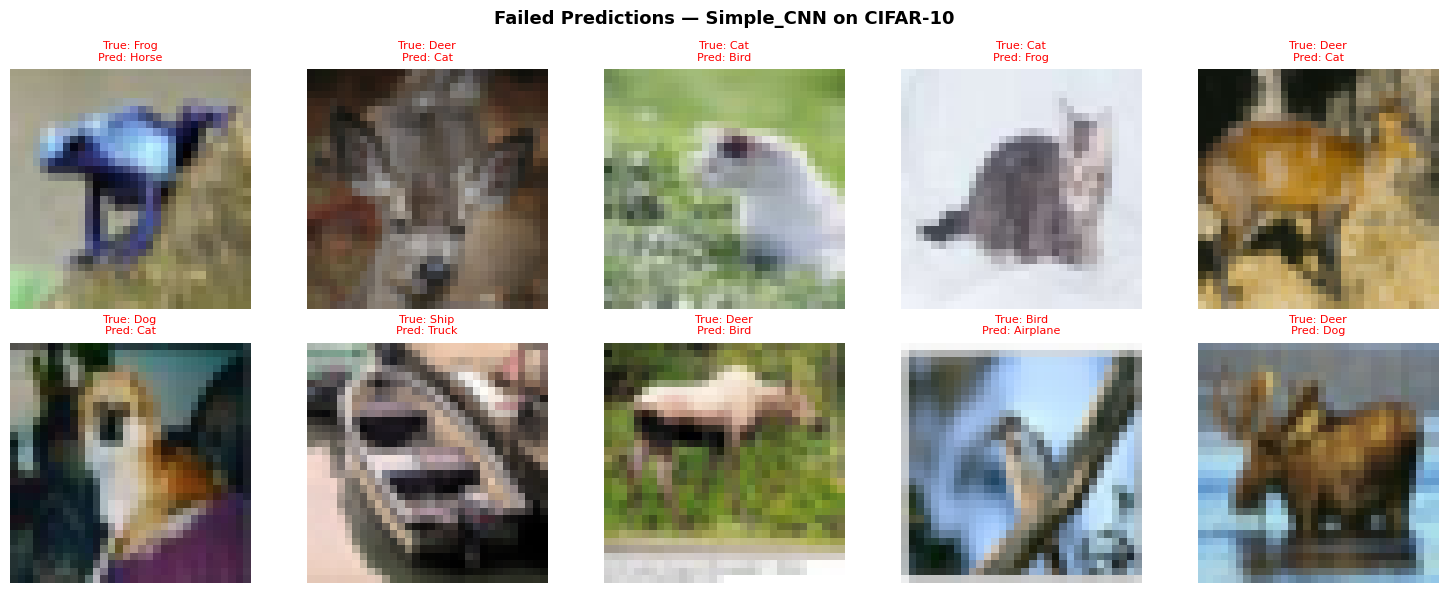

In [25]:
show_failed_predictions(
    model, x_test_cifar, y_test_cifar,
    CIFAR_CLASSES, model.name, 'CIFAR-10'
)

## 3. Deep CNN Model - Implementation & Testing

### Architecture

The **Deep CNN** follows a VGG-style design, stacking multiple convolutional layers per block before pooling. This allows the network to build richer feature representations at each spatial scale before reducing resolution.

**Layers (3 convolutional blocks):**
- Block 1: `Conv2D(32)` → `Conv2D(32)` → `BatchNorm` → `MaxPooling` → `Dropout(0.2)`
- Block 2: `Conv2D(64)` → `Conv2D(64)` → `BatchNorm` → `MaxPooling` → `Dropout(0.3)`
- Block 3: `Conv2D(128)` → `Conv2D(128)` → `BatchNorm` → `MaxPooling` → `Dropout(0.4)`
- `Flatten` → `Dense(256)` → `BatchNorm` → `Dropout(0.5)` → `Dense(10, softmax)`

**Double convolutions per block** (inspured by VGG) allow the network to learn more complex patterns before each pooling step.
**Progressive Dropout** (0.2 -> 0.3 -> 0.4 -> 0.5) applies stronger refulatization in deeper, more abstarct layers when overfitting is more likely.

### Training

- **Optimizer:** Adam (lr = 1e-3)
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 20, **Batch size:** 64
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping`

### Improvement over Simple CNN

Stacking two convolutions per block before pooling enables the model to learn more expressive features without aggressively reducing spatial resolution. The added depth, combined with BatchNormalization and progressive regulatization, yields a noticeable accuracy gain over the Simple CNN on both datasets.

In [26]:
def build_deep_cnn(input_shape, num_classes=10):
    """
    Deep CNN v1 — VGG-style with 3 conv blocks.
    - Filters: 32 → 64 → 128
    - BatchNorm after double conv
    - Flatten head
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Deep_CNN')
    return model

In [27]:
model = build_deep_cnn(x_train_fmnist.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_fmnist, y_train_fmnist, 
    x_test_fmnist, y_test_fmnist, epochs=20, patience=15)

<Sequential name=Deep_CNN, built=True>
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.7022 - loss: 0.8883 - val_accuracy: 0.8720 - val_loss: 0.3462 - learning_rate: 0.0010
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8595 - loss: 0.3858 - val_accuracy: 0.8727 - val_loss: 0.3772 - learning_rate: 0.0010
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8871 - loss: 0.3155 - val_accuracy: 0.9085 - val_loss: 0.2509 - learning_rate: 0.0010
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8984 - loss: 0.2821 - val_accuracy: 0.9088 - val_loss: 0.2490 - learning_rate: 0.0010
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9057 - loss: 0.2595 - val_accuracy: 0.9050 - val_loss: 0.2618 - learning_rate: 0.0010
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9106 - loss: 0.2444 - val_accuracy: 0.9213 - val_loss: 0.2161 - learning_rate: 0.0010
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/

In [28]:
results.append({
    'model':    model.name,
    'dataset':  'Fashion-MNIST',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

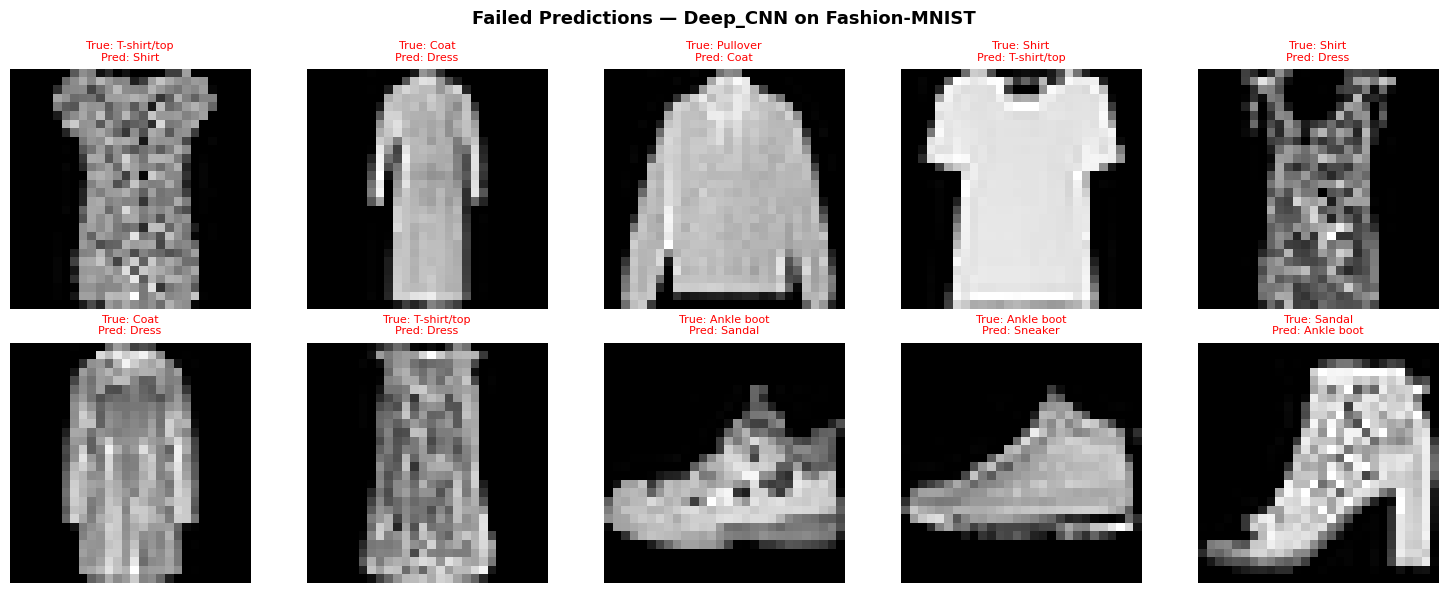

In [29]:
show_failed_predictions(
    model, x_test_fmnist, y_test_fmnist,
    FMNIST_CLASSES, model.name, 'Fashion-MNIST'
)

In [30]:
model = build_deep_cnn(x_train_cifar.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_cifar, y_train_cifar, 
    x_test_cifar, y_test_cifar, epochs=20, patience=15)

<Sequential name=Deep_CNN, built=True>
Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 20ms/step - accuracy: 0.3155 - loss: 2.2120 - val_accuracy: 0.4950 - val_loss: 1.4417 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5454 - loss: 1.2638 - val_accuracy: 0.5712 - val_loss: 1.2523 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6396 - loss: 1.0198 - val_accuracy: 0.6622 - val_loss: 0.9681 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.6886 - loss: 0.8842 - val_accuracy: 0.7060 - val_loss: 0.8472 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7227 - loss: 0.7946 - val_accuracy: 0.6938 - val_loss: 0.8996 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7410 - loss: 0.7324 - val_accuracy: 0.7238 - val_loss: 0.7874 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/

In [31]:
results.append({
    'model':    model.name,
    'dataset':  'CIFAR-10',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

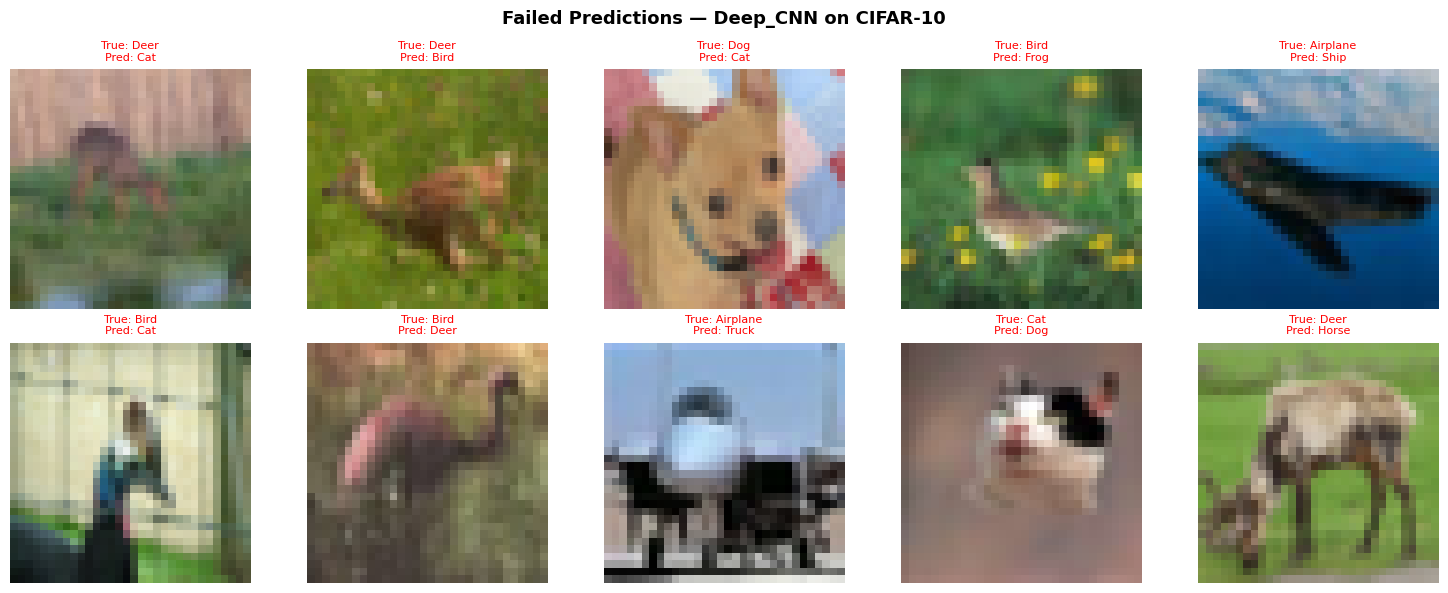

In [32]:
show_failed_predictions(
    model, x_test_cifar, y_test_cifar,
    CIFAR_CLASSES, model.name, 'CIFAR-10'
)

## 4. Deep CNN v2 — Implementation & Testing

### Architecture

**Deep CNN v2** refines the previous model with two key improvements: doubled filter sizes 
and a switch from `Flatten` to `GlobalAveragePooling2D`, following more modern CNN design principles.

**Layers (3 convolutional blocks):**
- Block 1: `Conv2D(64)` → `BatchNorm` → `ReLU` → `Conv2D(64)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.2)`
- Block 2: `Conv2D(128)` → `BatchNorm` → `ReLU` → `Conv2D(128)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.3)`
- Block 3: `Conv2D(256)` → `BatchNorm` → `ReLU` → `Conv2D(256)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.4)`
- `GlobalAveragePooling2D` → `Dense(256)` → `BatchNorm` → `Dropout(0.5)` → `Dense(10, softmax)`

### Key Changes from v1

- **Larger filters (64 → 128 → 256):** More expressive feature maps at every block, 
  allowing the network to capture richer patterns.
- **Conv → BN → ReLU ordering:** Normalizing pre-activation values leads to more stable 
  gradient flow compared to applying BatchNorm after the activation.
- **GlobalAveragePooling2D instead of Flatten:** Averages each feature map into a single 
  value, drastically reducing the number of parameters and overfitting risk in the head.

### Training

- **Optimizer:** Adam (lr = 1e-3)
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 20, **Batch size:** 64
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping`

### Improvement over Deep CNN v1

The architectural refinements in v2 yield a clear accuracy gain on both datasets. 
The larger filter sizes improve the model's capacity to learn complex features, while 
GlobalAveragePooling2D keeps the parameter count manageable and reduces overfitting, 
resulting in better generalization on the test set.


In [33]:
def build_deep_cnn_v2(input_shape, num_classes=10):
    """
    Deep CNN v2 — improved VGG-style with 3 conv blocks.
    Differences from v1:
    - Filters: 64 → 128 → 256 (doubled)
    - BatchNorm before activation (Conv → BN → ReLU pattern)
    - GlobalAveragePooling2D instead of Flatten
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='Deep_CNN_v2')
    return model

In [34]:
model = build_deep_cnn_v2(x_train_fmnist.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_fmnist, y_train_fmnist, 
    x_test_fmnist, y_test_fmnist, patience=10, epochs=50)

<Sequential name=Deep_CNN_v2, built=True>
Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - accuracy: 0.7103 - loss: 0.8280 - val_accuracy: 0.8808 - val_loss: 0.3284 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8716 - loss: 0.3524 - val_accuracy: 0.8953 - val_loss: 0.2921 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.8951 - loss: 0.2941 - val_accuracy: 0.9047 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9083 - loss: 0.2585 - val_accuracy: 0.9133 - val_loss: 0.2454 - learning_rate: 0.0010
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9145 - loss: 0.2373 - val_accuracy: 0.9232 - val_loss: 0.2174 - learning_rate: 0.0010
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9216 - loss: 0.2226 - val_accuracy: 0.9160 - val_loss: 0.2446 - learning_rate: 0.0010
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━

In [35]:
results.append({
    'model':    model.name,
    'dataset':  'Fashion-MNIST',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

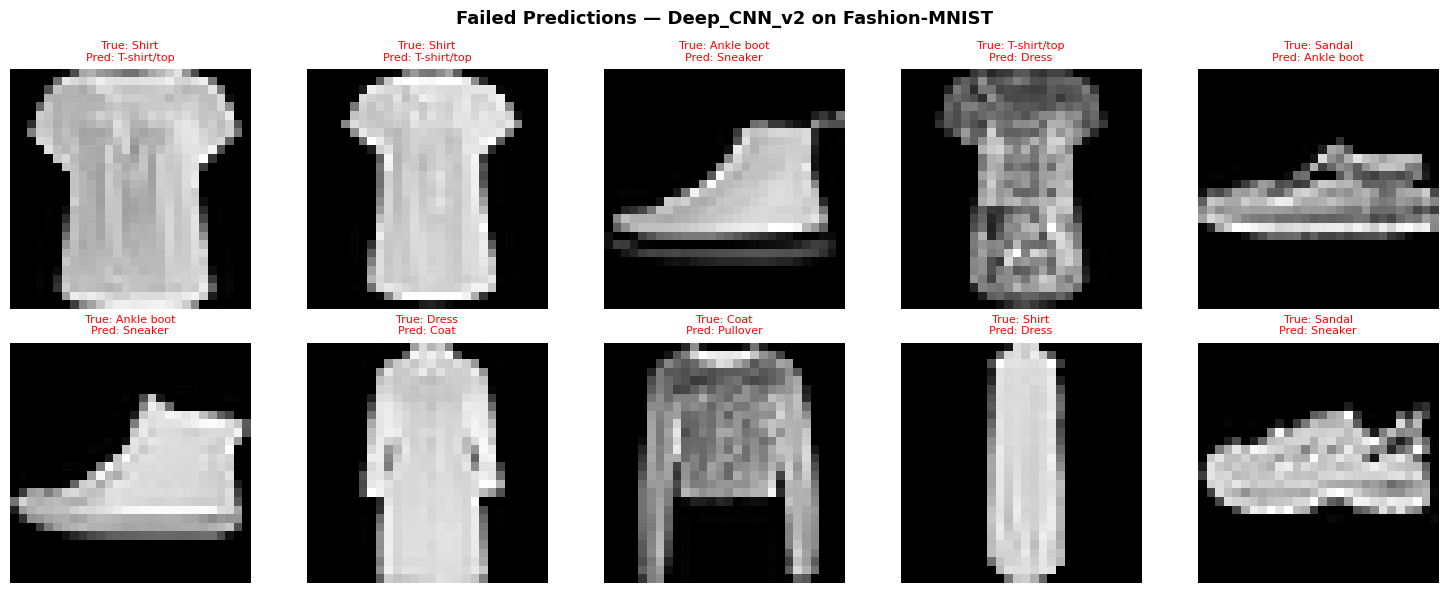

In [36]:
show_failed_predictions(
    model, x_test_fmnist, y_test_fmnist,
    FMNIST_CLASSES, model.name, 'Fashion-MNIST'
)

In [37]:
model = build_deep_cnn_v2(x_train_cifar.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_cifar, y_train_cifar, 
    x_test_cifar, y_test_cifar, patience=10, epochs=50)

<Sequential name=Deep_CNN_v2, built=True>
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 32ms/step - accuracy: 0.3537 - loss: 1.9211 - val_accuracy: 0.4492 - val_loss: 1.8713 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6156 - loss: 1.0726 - val_accuracy: 0.5792 - val_loss: 1.3317 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.6933 - loss: 0.8676 - val_accuracy: 0.5782 - val_loss: 1.4085 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.7416 - loss: 0.7427 - val_accuracy: 0.7026 - val_loss: 0.9157 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7745 - loss: 0.6548 - val_accuracy: 0.7394 - val_loss: 0.8084 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.7948 - loss: 0.5892 - val_accuracy: 0.6710 - val_loss: 1.1248 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━

In [38]:
results.append({
    'model':    model.name,
    'dataset':  'CIFAR-10',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

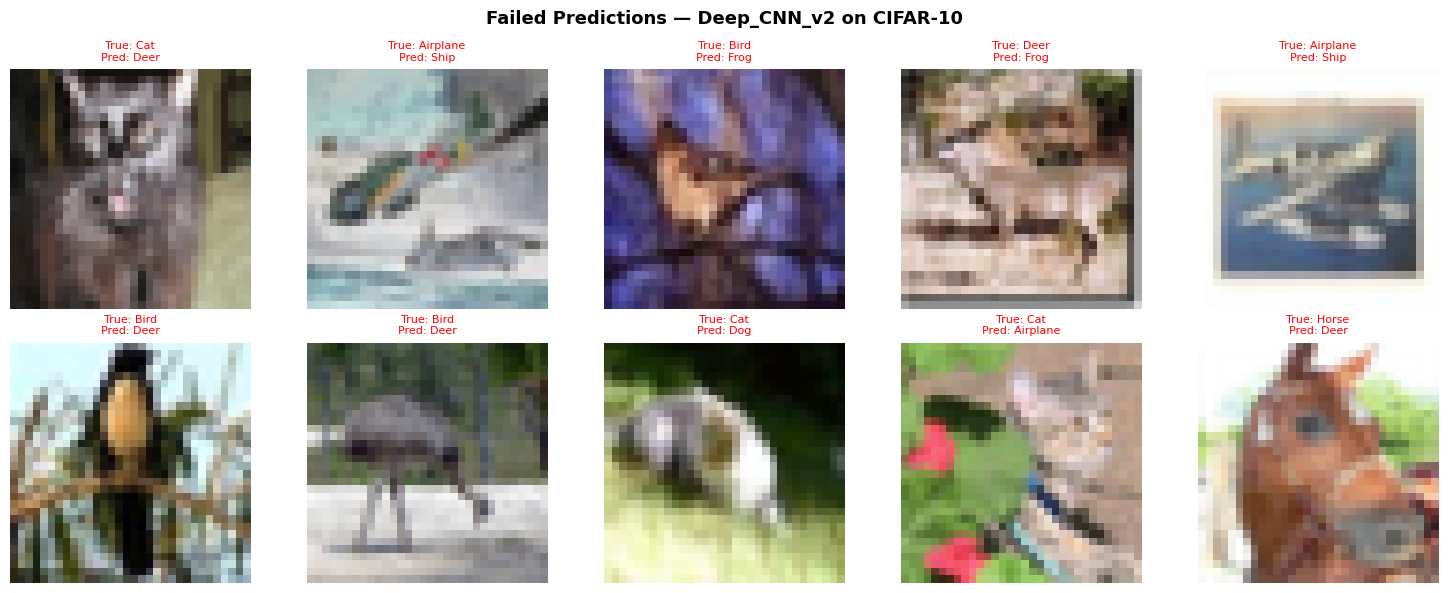

In [39]:
show_failed_predictions(
    model, x_test_cifar, y_test_cifar,
    CIFAR_CLASSES, model.name, 'CIFAR-10'
)

## 5. CNN with Data Augmentation — Implementation & Testing

### Architecture

This model extends Deep CNN v2 by introducing an **on-the-fly data augmentation pipeline** 
and an additional convolutional block, pushing the network's capacity further while actively 
combating overfitting through artificial data diversity.

**Augmentation layers (applied during training only):**
- `RandomFlip(horizontal)` — mirrors the image horizontally
- `RandomRotation(0.05)` — slightly rotates the image
- `RandomZoom(0.05)` — slightly zooms in or out

**Layers (4 convolutional blocks):**
- Block 1: `Conv2D(64)` → `BatchNorm` → `ReLU` → `Conv2D(64)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.2)`
- Block 2: `Conv2D(128)` → `BatchNorm` → `ReLU` → `Conv2D(128)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.3)`
- Block 3: `Conv2D(256)` → `BatchNorm` → `ReLU` → `Conv2D(256)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.4)`
- Block 4: `Conv2D(512)` → `BatchNorm` → `ReLU` → `Conv2D(512)` → `BatchNorm` → `ReLU` → `MaxPooling` → `Dropout(0.4)`
- `GlobalAveragePooling2D` → `Dense(256)` → `BatchNorm` → `Dropout(0.5)` → `Dense(10, softmax)`

### Why Data Augmentation?

Augmentation artificially expands the training set by creating realistic variations of 
existing images. This forces the model to learn features that are invariant to small 
geometric transformations, improving generalization without collecting new data. 
The transformations were kept subtle (small rotation and zoom factors) to avoid 
distorting the images beyond recognition.

### Training

- **Optimizer:** Adam (lr = 1e-3)
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 20, **Batch size:** 64
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping`

### Improvement over Deep CNN v2

The combination of data augmentation and the additional convolutional block produces 
the best results among the custom CNN models. The gains are especially notable on 
CIFAR-10, where the added variety in training samples helps the model generalize to 
the more diverse and complex photorealistic images.


In [67]:
def build_cnn_with_augmentation(input_shape, num_classes=10):
    """
    Improved augmentation CNN — same as build_cnn_with_augmentation() but with:
    - Less aggressive augmentation (0.05 instead of 0.1)
    - No RandomTranslation
    - Larger filters (64→128→256)
    - GlobalAveragePooling2D instead of Flatten
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Milder augmentation
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),

        # Block 1
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        # Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax'),
    ], name='CNN_Augmentation')
    return model

In [ ]:
model = build_cnn_with_augmentation(x_train_fmnist.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_fmnist, y_train_fmnist,
    x_test_fmnist, y_test_fmnist, patience=10, epochs=50)

<Sequential name=CNN_Augmentation, built=True>
Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 25s 24ms/step - accuracy: 0.6650 - loss: 0.9984 - val_accuracy: 0.8363 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8337 - loss: 0.4587 - val_accuracy: 0.8558 - val_loss: 0.4015 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8630 - loss: 0.3827 - val_accuracy: 0.8530 - val_loss: 0.4123 - learning_rate: 0.0010
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8744 - loss: 0.3471 - val_accuracy: 0.8872 - val_loss: 0.3038 - learning_rate: 0.0010
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8813 - loss: 0.3242 - val_accuracy: 0.8952 - val_loss: 0.2917 - learning_rate: 0.0010
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 20s 24ms/step - accuracy: 0.8902 - loss: 0.3052 - val_accuracy: 0.9045 - val_loss: 0.2687 - learning_rate: 0.0010
Epoch 7/50
844/844 ━━━━━━━━━━

In [ ]:
results.append({
    'model':    model.name,
    'dataset':  'Fashion-MNIST',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

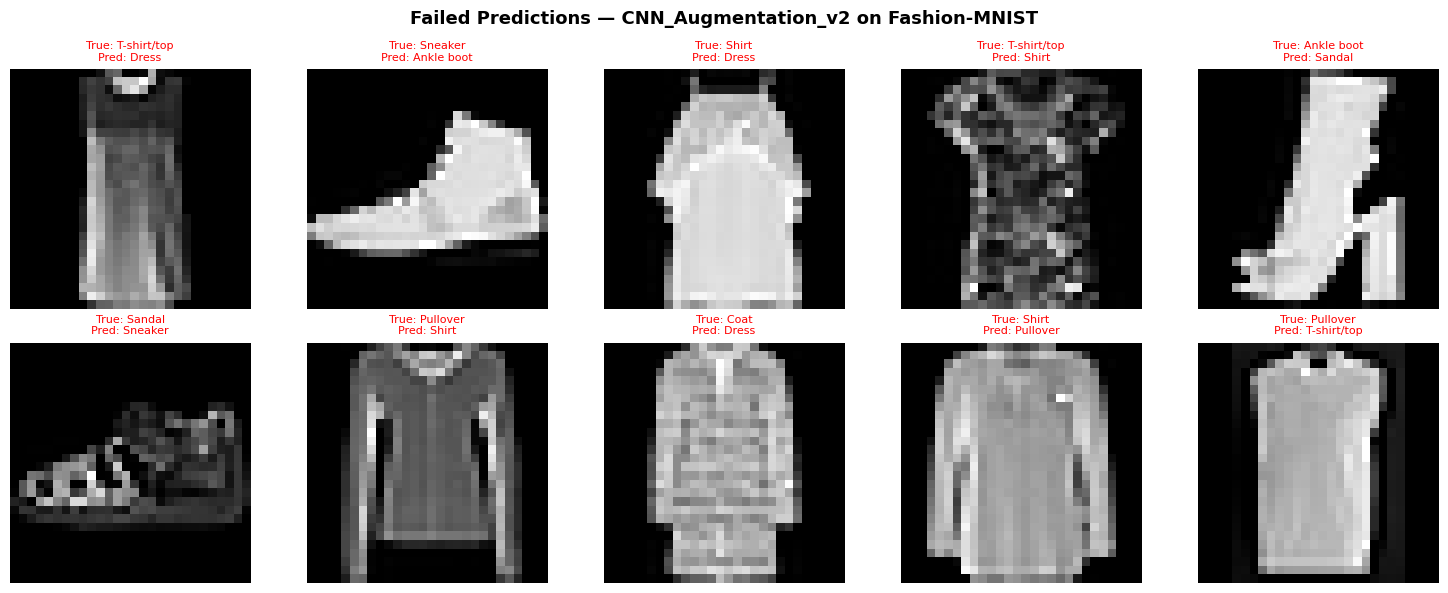

In [43]:
show_failed_predictions(
    model, x_test_fmnist, y_test_fmnist,
    FMNIST_CLASSES, model.name, 'Fashion-MNIST'
)

In [ ]:
model = build_cnn_with_augmentation(x_train_cifar.shape[1:])
print(model)

hist, acc, loss = compile_and_train(model, x_train_cifar, y_train_cifar, 
    x_test_cifar, y_test_cifar, patience=10, epochs=50)

<Sequential name=CNN_Augmentation_v2, built=True>
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.2891 - loss: 2.2436 - val_accuracy: 0.5194 - val_loss: 1.3579 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.5126 - loss: 1.3605 - val_accuracy: 0.5578 - val_loss: 1.3869 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6011 - loss: 1.1173 - val_accuracy: 0.6248 - val_loss: 1.0967 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6531 - loss: 0.9753 - val_accuracy: 0.6974 - val_loss: 0.8882 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.6935 - loss: 0.8788 - val_accuracy: 0.6346 - val_loss: 1.2130 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.7241 - loss: 0.7974 - val_accuracy: 0.7322 - val_loss: 0.7962 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━

In [ ]:
results.append({
    'model':    model.name,
    'dataset':  'CIFAR-10',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

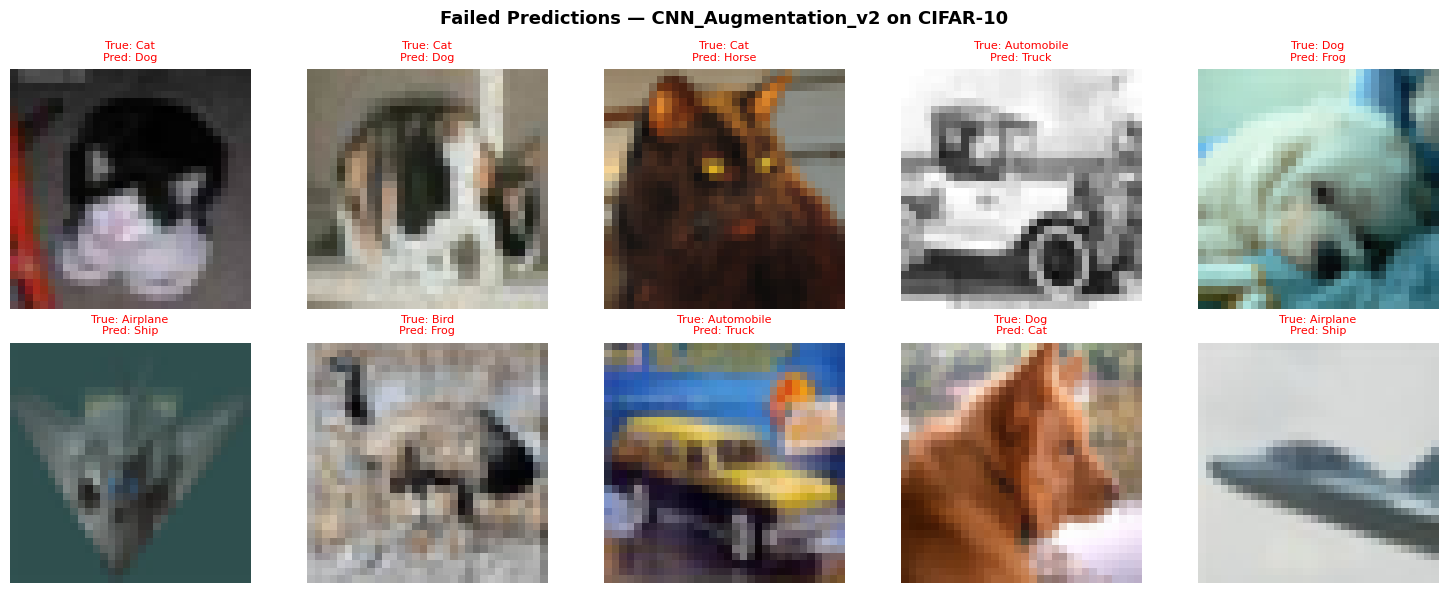

In [46]:
show_failed_predictions(
    model, x_test_cifar, y_test_cifar,
    CIFAR_CLASSES, model.name, 'CIFAR-10'
)

## 6. ResNet from Scratch — Implementation & Testing

### Architecture

**ResNet (Residual Network)** introduces the concept of **skip connections** (residual 
connections), which allow the gradient to flow directly through the network by bypassing 
one or more layers. This solves the **vanishing gradient problem** that makes very deep 
networks difficult to train, enabling the construction of much deeper models without 
degradation in performance.

**Entry block:**
- `Conv2D(64)` → `BatchNorm` → `ReLU`

**Residual Block structure:**
Each residual block computes `F(x) + x`, where `F(x)` is the output of two stacked 
convolutions and `x` is the identity shortcut:
- `Conv2D(filters)` → `BatchNorm` → `ReLU` → `Conv2D(filters)` → `BatchNorm`
- Add shortcut → `ReLU`
- When the number of filters changes between blocks, a `1×1 Conv2D` projection is 
  applied to the shortcut to match dimensions.

**3 residual blocks with increasing filters (64 → 128 → 256):**
- Block 1: 2 residual units, 64 filters
- Block 2: 2 residual units, 128 filters (with downsampling)
- Block 3: 2 residual units, 256 filters (with downsampling)

**Head:**
- `GlobalAveragePooling2D` → `Dense(256)` → `BatchNorm` → `Dropout(0.5)` → `Dense(10, softmax)`

### Why Residual Connections?

In plain deep networks, stacking many layers can cause gradients to vanish during 
backpropagation, making training ineffective. Skip connections provide a direct path 
for gradients to flow back through the network, allowing much deeper architectures 
to be trained reliably. Even if a block learns nothing useful, the identity shortcut 
ensures no information is lost.

### Training

- **Optimizer:** Adam (lr = 1e-3)
- **Loss:** Sparse Categorical Crossentropy
- **Epochs:** 50, **Batch size:** 64
- Callbacks: `ReduceLROnPlateau`, `EarlyStopping`

### Improvement over previous CNNs

By enabling deeper feature extraction through residual connections, ResNet captures 
more abstract and discriminative representations than the plain VGG-style models. 
This is particularly beneficial for CIFAR-10, where the increased model depth helps 
distinguish between visually similar classes such as cats and dogs.


In [47]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    # Match dimensions if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding='same')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_resnet_scratch(input_shape, num_classes=10):
    inputs = layers.Input(shape=input_shape)
    
    # Entry block
    x = layers.Conv2D(64, (3,3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Residual blocks
    x = residual_block(x, 64)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)
    
    x = residual_block(x, 128)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.3)(x)
    
    x = residual_block(x, 256)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.4)(x)
    
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    return keras.Model(inputs, outputs, name='ResNet_Scratch')

In [48]:
# ResNet from scratch
model = build_resnet_scratch(x_train_fmnist.shape[1:])
print(model)

hist, acc, loss = compile_and_train(
    model, x_train_fmnist, y_train_fmnist,
    x_test_fmnist, y_test_fmnist,
    epochs=50, patience=10
)

<Functional name=ResNet_Scratch, built=True>
Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.6881 - loss: 0.9036 - val_accuracy: 0.8665 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8709 - loss: 0.3589 - val_accuracy: 0.9063 - val_loss: 0.2612 - learning_rate: 0.0010
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.8939 - loss: 0.2995 - val_accuracy: 0.8930 - val_loss: 0.3059 - learning_rate: 0.0010
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9044 - loss: 0.2664 - val_accuracy: 0.8880 - val_loss: 0.3229 - learning_rate: 0.0010
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9136 - loss: 0.2419 - val_accuracy: 0.8862 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.9273 - loss: 0.2044 - val_accuracy: 0.9245 - val_loss: 0.2095 - learning_rate: 5.0000e-04
Epoch 7/50
844/844 ━━━━━━━━

In [49]:
results.append({
    'model':    model.name,
    'dataset':  'Fashion-MNIST',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

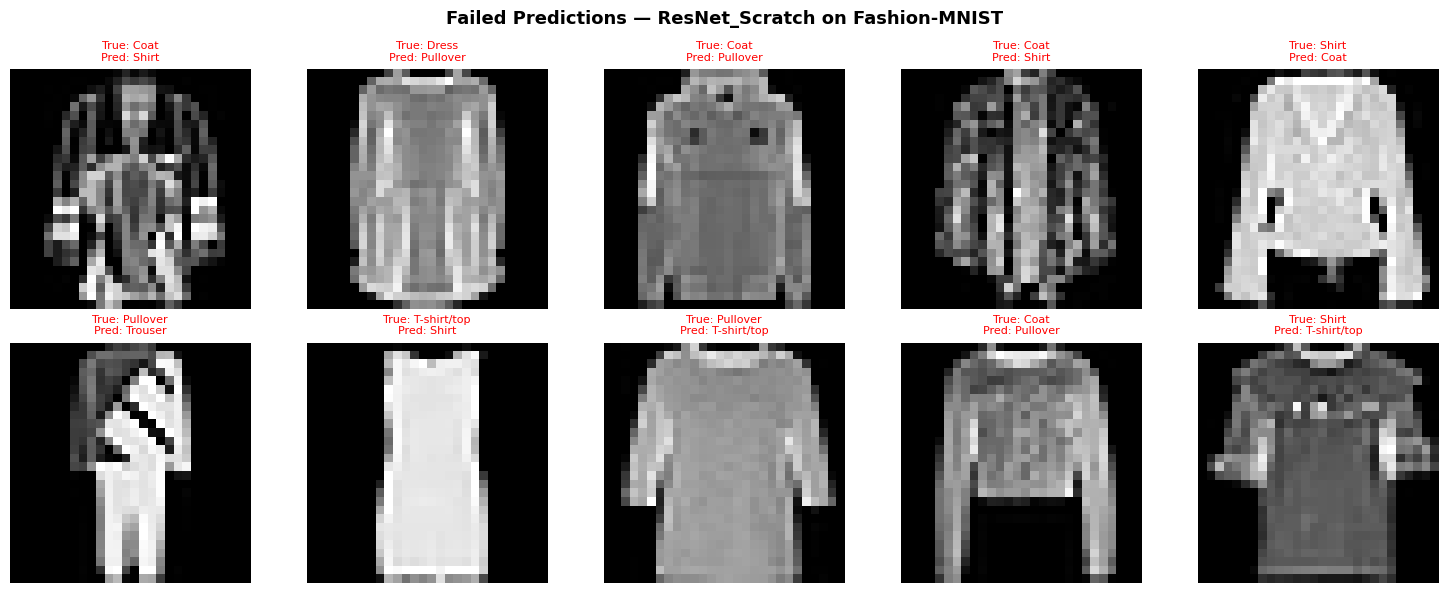

In [50]:
show_failed_predictions(
    model, x_test_fmnist, y_test_fmnist,
    FMNIST_CLASSES, model.name, 'Fashion-MNIST'
)

In [52]:
# ResNet from scratch
model = build_resnet_scratch(x_train_cifar.shape[1:])
print(model)

hist, acc, loss = compile_and_train(
    model, x_train_cifar, y_train_cifar,
    x_test_cifar, y_test_cifar,
    epochs=50, patience=10
)


<Functional name=ResNet_Scratch, built=True>
Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 38ms/step - accuracy: 0.3340 - loss: 1.9698 - val_accuracy: 0.4948 - val_loss: 1.4231 - learning_rate: 0.0010
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5939 - loss: 1.1261 - val_accuracy: 0.4526 - val_loss: 2.1881 - learning_rate: 0.0010
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.6651 - loss: 0.9423 - val_accuracy: 0.5804 - val_loss: 1.3344 - learning_rate: 0.0010
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7168 - loss: 0.8071 - val_accuracy: 0.6476 - val_loss: 1.0959 - learning_rate: 0.0010
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 25ms/step - accuracy: 0.7550 - loss: 0.7059 - val_accuracy: 0.6868 - val_loss: 0.9865 - learning_rate: 0.0010
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.7817 - loss: 0.6278 - val_accuracy: 0.7178 - val_loss: 0.8162 - learning_rate: 0.0010
Epoch 7/50
704/704 ━━━━━━━━━━━━

In [53]:
results.append({
    'model':    model.name,
    'dataset':  'CIFAR-10',
    'accuracy': acc,
    'loss':     loss,
    'history':  hist
})

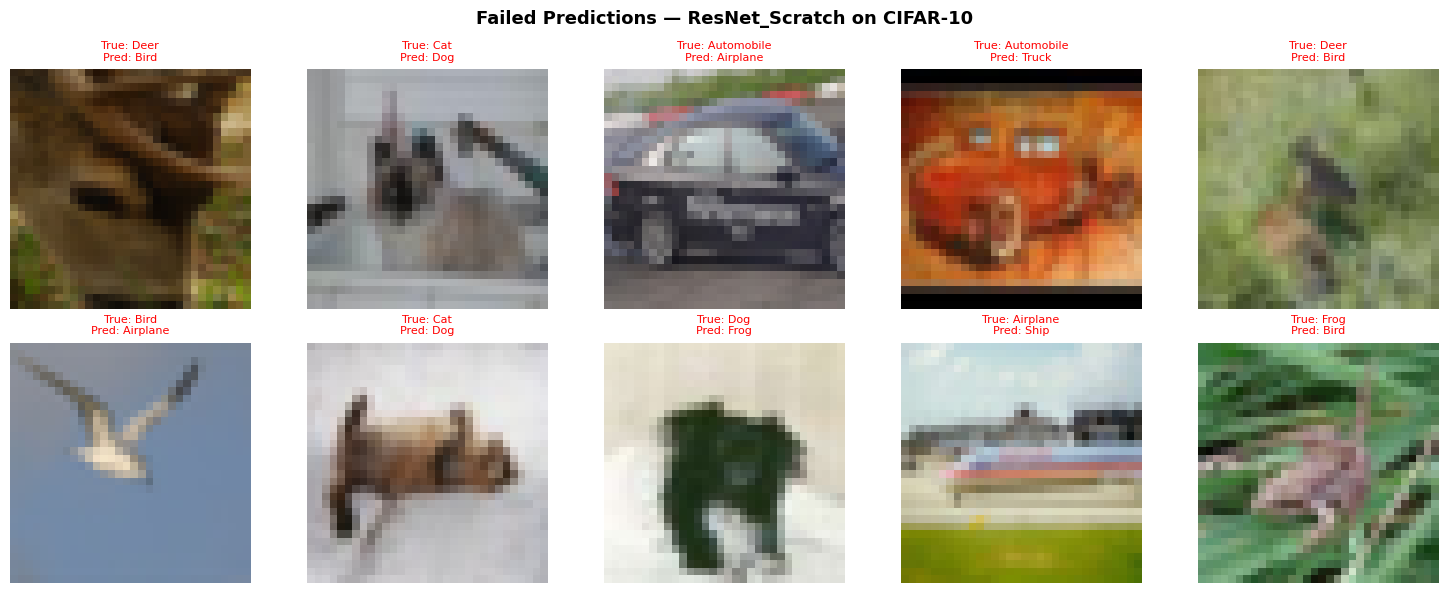

In [54]:
show_failed_predictions(
    model, x_test_cifar, y_test_cifar,
    CIFAR_CLASSES, model.name, 'CIFAR-10'
)

## Plot results

In [ ]:
def print_summary_table(results):
    """Print ranked summary table per dataset."""
    df = pd.DataFrame([{k: v for k, v in r.items() if k != 'history'}
                       for r in results])

    for dataset in ['Fashion-MNIST', 'CIFAR-10']:
        print(f"\n{'='*55}")
        print(f"  {dataset}")
        print(f"{'='*55}")
        subset = df[df['dataset'] == dataset]\
                   .sort_values('accuracy', ascending=False)\
                   .reset_index(drop=True)
        subset.index += 1
        print(subset[['model', 'accuracy', 'loss']].to_string())

print_summary_table(results)



  Fashion-MNIST
                 model  accuracy      loss
1       ResNet_Scratch    0.9449  0.233057
2          Deep_CNN_v2    0.9435  0.274649
3  CNN_Augmentation_v2    0.9419  0.180626
4             Deep_CNN    0.9314  0.196329
5           Simple_CNN    0.9244  0.291502
6                  MLP    0.8848  0.329607

  CIFAR-10
                 model  accuracy      loss
1       ResNet_Scratch    0.8940  0.471123
2          Deep_CNN_v2    0.8932  0.473501
3  CNN_Augmentation_v2    0.8844  0.369243
4             Deep_CNN    0.8394  0.501849
5           Simple_CNN    0.7166  0.873490
6                  MLP    0.5072  1.390600


## Results Summary

### Fashion-MNIST

All CNN-based models achieve strong results, with the top three separated by less than 
0.3%, suggesting the dataset is near saturation for these architectures.

- **ResNet_Scratch** achieves the highest accuracy (94.49%), benefiting from its deeper 
  feature extraction through residual connections.
- **Deep_CNN_v2** follows closely (94.35%), showing that modern design choices 
  (larger filters, GlobalAveragePooling) alone can match residual networks on simpler datasets.
- **CNN_Augmentation_v2**, while ranked 3rd in accuracy, achieves the **lowest loss 
  (0.1806)** of all models — indicating it generalizes most reliably and is the least 
  overconfident in its predictions.
- **MLP** trails significantly at 88.48%, confirming that spatial feature extraction 
  is important even for a relatively simple dataset like Fashion-MNIST.

### CIFAR-10

The results spread much wider on CIFAR-10, reflecting the increased difficulty of the task.

- **ResNet_Scratch** again leads (89.40%), with residual connections proving critical 
  for learning the richer, more complex features required by photorealistic images.
- **Deep_CNN_v2** is nearly identical (89.32%), a strong result for a model without 
  skip connections or augmentation.
- **CNN_Augmentation_v2** again achieves the **lowest loss (0.3692)**, confirming 
  that augmentation produces the most well-calibrated and generalizable model, even if 
  raw accuracy is marginally lower.
- The gap between **Simple_CNN (71.66%)** and the deeper models is far larger than on 
  Fashion-MNIST, highlighting how CIFAR-10 demands greater model capacity.
- **MLP (50.72%)** is essentially at chance level for a 10-class problem, 
  demonstrating that flat pixel representations are entirely insufficient for 
  complex image classification.


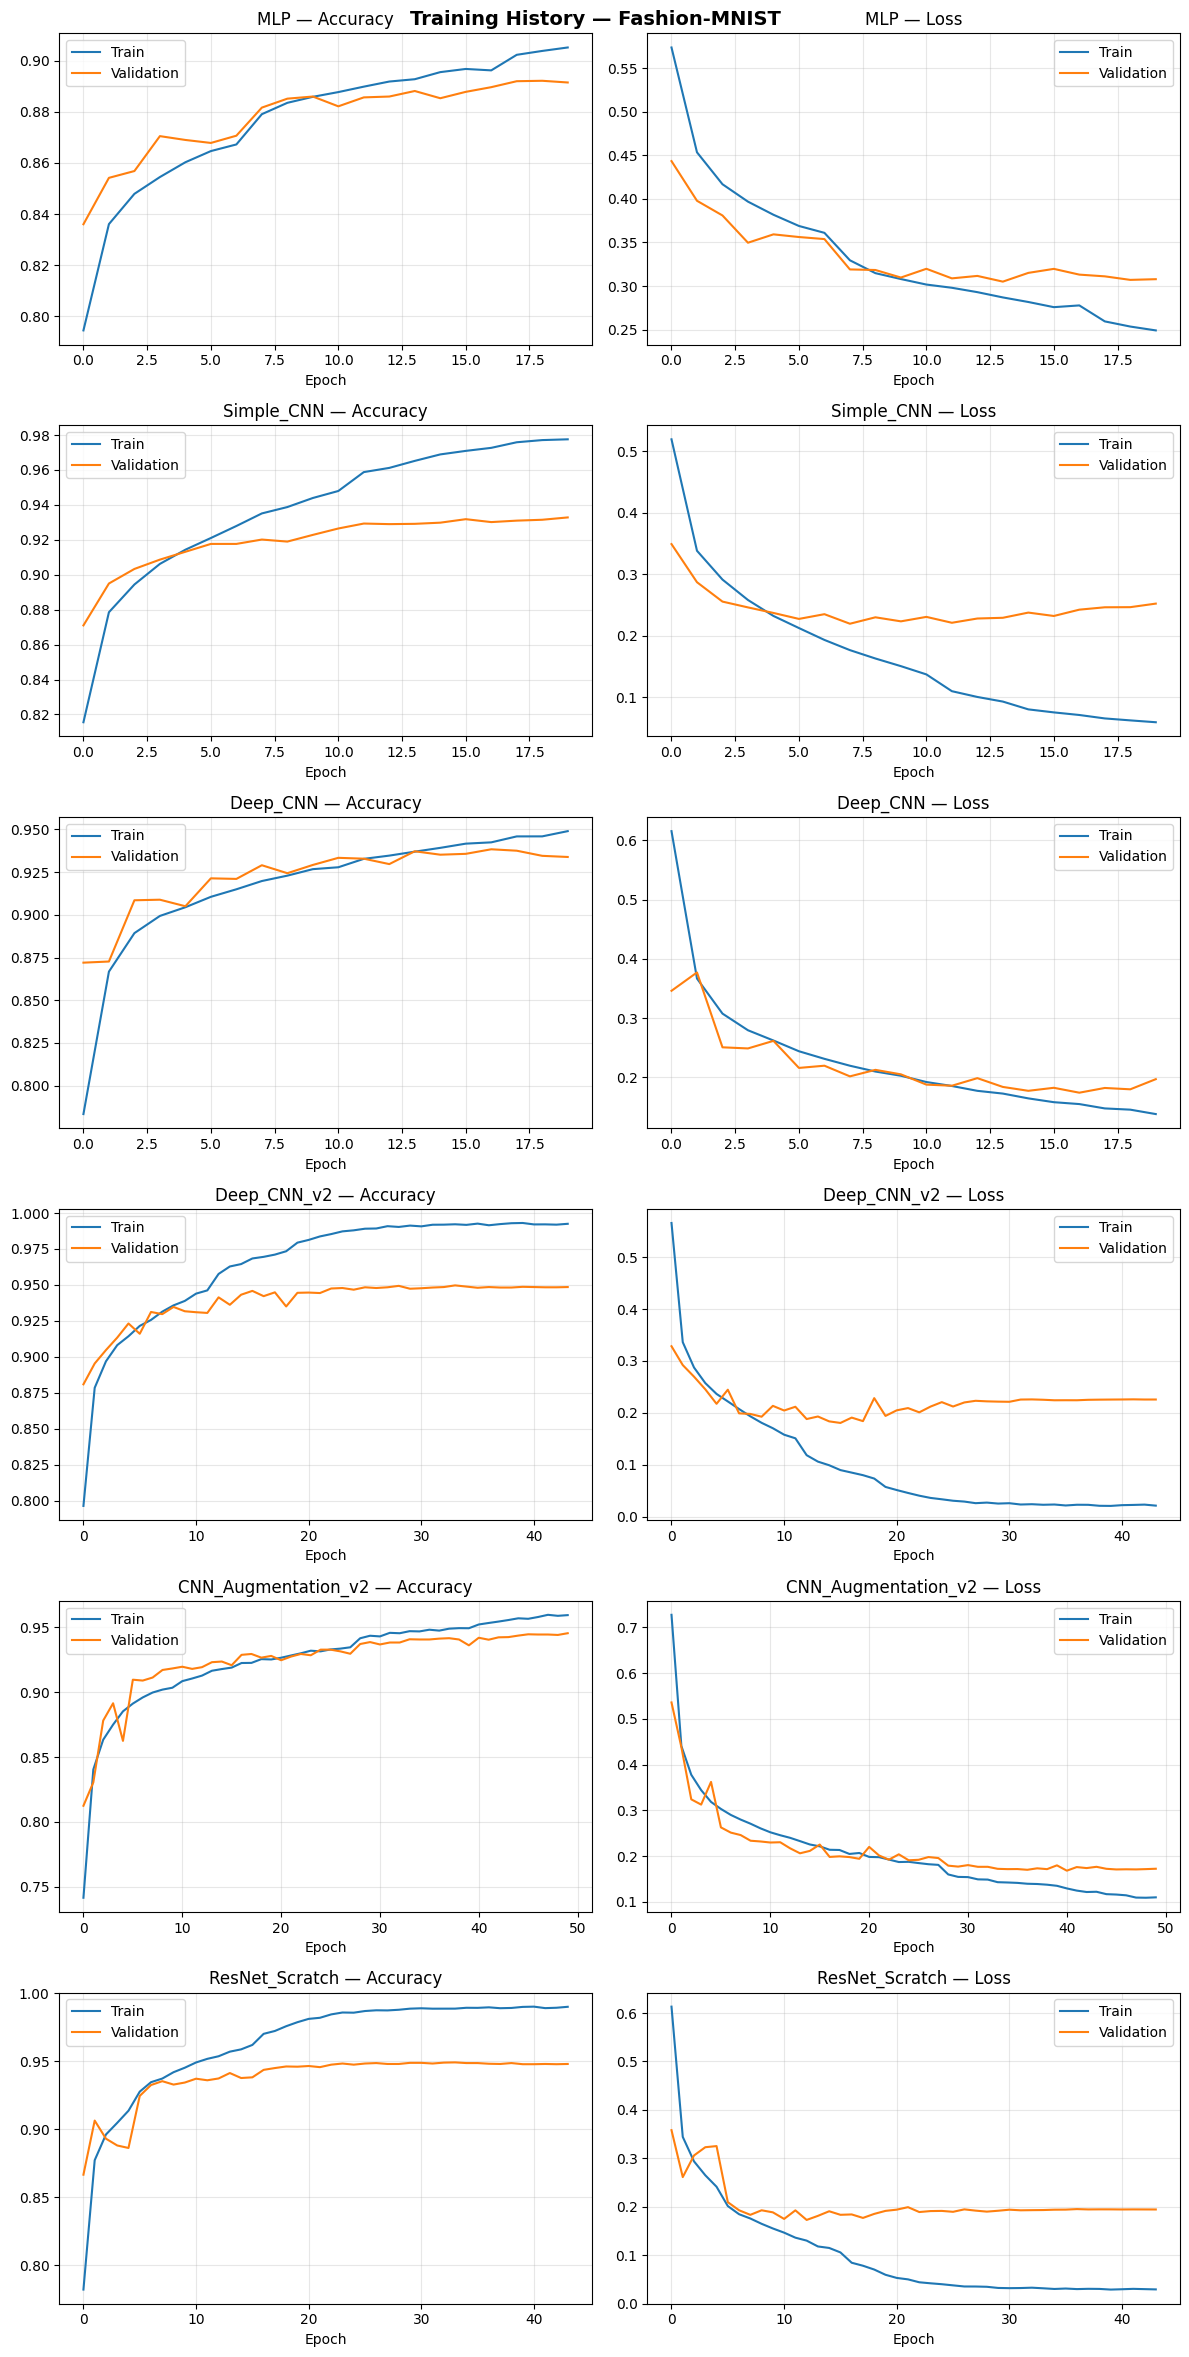

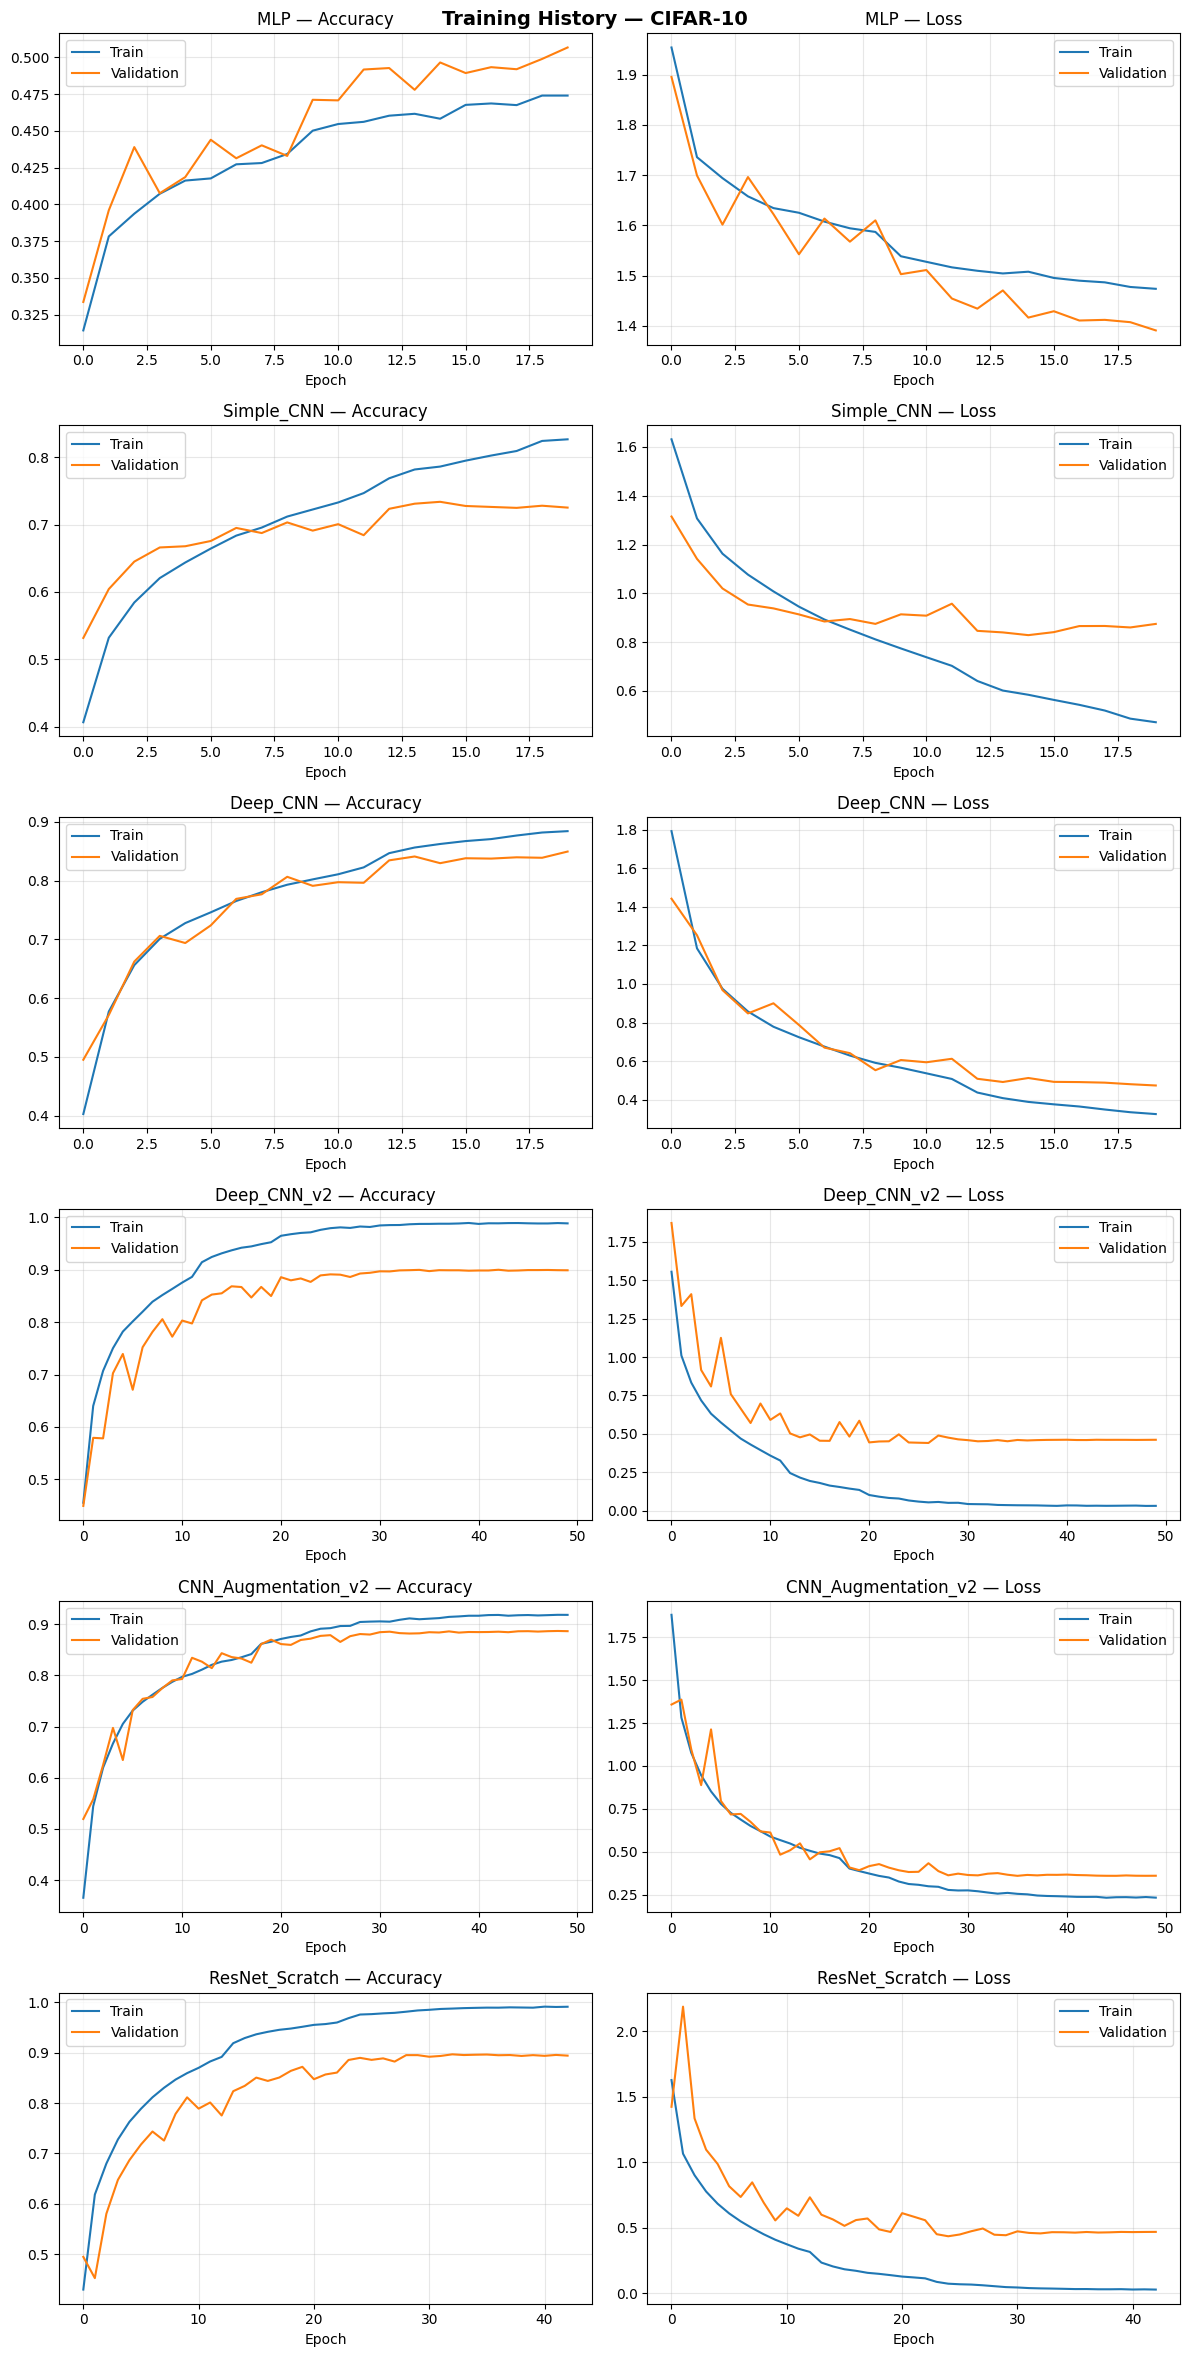

In [ ]:
def plot_all_histories(results):
    """Training curves for all models grouped by dataset."""
    for dataset in ['Fashion-MNIST', 'CIFAR-10']:
        entries = [r for r in results if r['dataset'] == dataset]
        n = len(entries)

        fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
        fig.suptitle(f'Training History — {dataset}', fontsize=14, fontweight='bold')

        if n == 1:
            axes = [axes]

        for i, entry in enumerate(entries):
            h = entry['history'].history
            axes[i][0].plot(h['accuracy'],     label='Train')
            axes[i][0].plot(h['val_accuracy'], label='Validation')
            axes[i][0].set_title(f"{entry['model']} — Accuracy")
            axes[i][0].set_xlabel('Epoch')
            axes[i][0].legend()
            axes[i][0].grid(True, alpha=0.3)

            axes[i][1].plot(h['loss'],     label='Train')
            axes[i][1].plot(h['val_loss'], label='Validation')
            axes[i][1].set_title(f"{entry['model']} — Loss")
            axes[i][1].set_xlabel('Epoch')
            axes[i][1].legend()
            axes[i][1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

plot_all_histories(results)

## Training History Analysis

### Fashion-MNIST

The models converge quickly and generally generalize well on Fashion-MNIST due to 
the dataset's relative simplicity (grayscale, low variance between samples).

- **MLP:** Train and validation curves track closely (~89%), indicating minimal overfitting 
  but also limited capacity — the model cannot extract more signal from pixel values alone.
- **Simple CNN & Deep CNN:** A growing gap between train and validation accuracy 
  appears as depth increases, suggesting the models start memorizing training data.
- **Deep CNN v2:** The train accuracy reaches near 100% while validation plateaus at ~95%, 
  a clear sign of overfitting despite Dropout and BatchNorm.
- **CNN Augmentation v2:** The train/validation gap narrows significantly compared to v2, 
  confirming that augmentation is effective at reducing overfitting even on this simpler dataset.
- **ResNet:** Behaves similarly to Deep CNN v2 — strong validation performance (~94.5%) 
  but with heavy overfitting on the training set.

### CIFAR-10

CIFAR-10 is significantly harder, and overfitting is much more pronounced across all models.

- **MLP:** Both curves plateau below 50%, essentially at chance level for a 10-class problem. 
  The MLP simply cannot learn meaningful features from raw pixels of complex color images.
- **Simple CNN & Deep CNN:** The train/validation gap is large and grows with depth, 
  reflecting overfitting on a dataset that demands stronger regularization.
- **Deep CNN v2 & ResNet:** Train accuracy reaches 100% while validation stalls at ~90%, 
  showing severe overfitting despite regularization techniques.
- **CNN Augmentation v2:** The most balanced curves of all — train and validation accuracy 
  stay close throughout training, demonstrating that data augmentation is the single most 
  effective tool for combating overfitting on CIFAR-10.


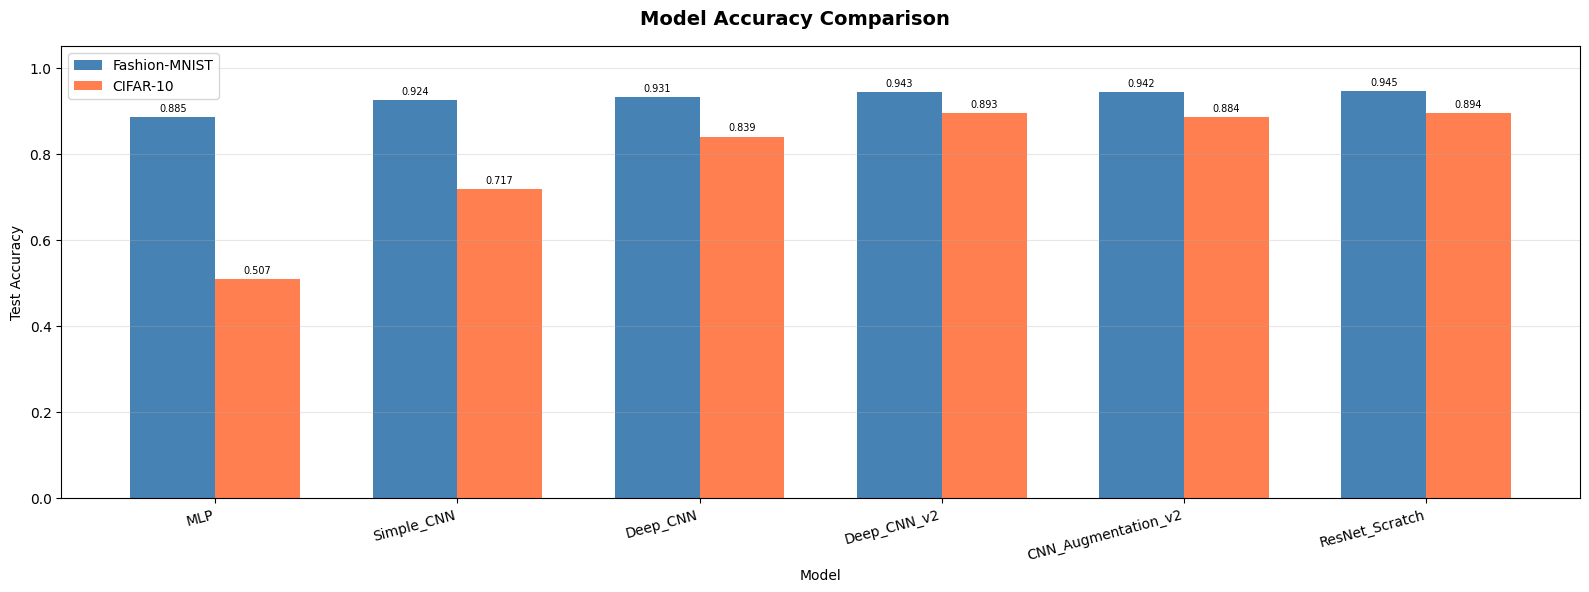

In [ ]:
def plot_accuracy_comparison(results):
    """Bar chart comparing all models with side-by-side bars per dataset."""
    df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('history', 'model_obj')}
                       for r in results])

    models   = df['model'].unique()
    x        = np.arange(len(models))
    width    = 0.35

    fig, ax = plt.subplots(figsize=(16, 6))
    fig.suptitle('Model Accuracy Comparison', fontsize=14, fontweight='bold')

    fmnist_accs = [df[(df['model'] == m) & (df['dataset'] == 'Fashion-MNIST')]['accuracy'].values[0]
                   if len(df[(df['model'] == m) & (df['dataset'] == 'Fashion-MNIST')]) > 0 else 0
                   for m in models]

    cifar_accs  = [df[(df['model'] == m) & (df['dataset'] == 'CIFAR-10')]['accuracy'].values[0]
                   if len(df[(df['model'] == m) & (df['dataset'] == 'CIFAR-10')]) > 0 else 0
                   for m in models]

    bars1 = ax.bar(x - width/2, fmnist_accs, width, label='Fashion-MNIST', color='steelblue')
    bars2 = ax.bar(x + width/2, cifar_accs,  width, label='CIFAR-10',      color='coral')

    ax.set_xlabel('Model')
    ax.set_ylabel('Test Accuracy')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # Value labels on bars
    for bar in bars1:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    for bar in bars2:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.01,
                    f'{h:.3f}', ha='center', va='bottom', fontsize=7)

    plt.tight_layout()
    plt.show()

plot_accuracy_comparison(results)

## Model Accuracy Comparison

The bar chart summarizes test accuracy across all models and both datasets, making 
two trends immediately clear.

**Consistent improvement with architectural complexity:**  
Both datasets follow a clear upward trend from MLP through to ResNet_Scratch. Each 
architectural advancement — deeper layers, better regularization, skip connections — 
translates directly into accuracy gains.

**The gap between datasets narrows as models improve:**  
The most striking pattern in the chart is how the orange (CIFAR-10) bars catch up 
to the blue (Fashion-MNIST) bars as complexity increases. The MLP shows a gap of 
~38 percentage points (0.885 vs 0.507), while ResNet reduces this to just ~5 points 
(0.945 vs 0.894). This shows that CIFAR-10 benefits far more from architectural 
improvements than Fashion-MNIST, which is already well-solved by simple CNNs.

**Fashion-MNIST plateaus early:**  
The blue bars grow very slowly after Simple_CNN (0.924), suggesting that the dataset 
is not challenging enough to differentiate the stronger models. CIFAR-10, on the other 
hand, continues to reward every architectural improvement significantly.

**Overall**, the results confirm that CNNs with sufficient depth, regularization, and 
residual connections are the right tool for image classification, with ResNet_Scratch 
achieving the best balance of performance across both datasets.


## Conclusions

This project explored image classification across two datasets using six architectures of increasing complexity, from a single MLP to a custom ResNet.

**Key takeaways:**

- **MLPs are inadequate for image classification.** Treating images as flat vectors discards all spatial information, leading to poor performance especially on complex datasets like CIFAR-10 (~50%, near chance level).
- **Depth and spatial awareness matter.** Each step up in CNN complexity - more layers, larger filters, better normalization - consistently improved accuracy on both datasets.
- **CIFAR-10 is significantly harder than Fashion-MNIST.**. The dataset's photorealistic diversity demands stronger models and regularization. Simple architectures that work well on Fashion-MNIST fail to generalize on CIFAR-10.
- **Data augmentation is the most effective regularization stragey.**. CNN_Augmentation achieved the lower test loss on both datasets, producing the most well-calibrated and generalizable predictions - even when not ranking first in raw accuracy.
- **Residual connections push performance the furthest.** ResNet_Scratch topped both leaderboards, demonstrating that skip connections enable deeper, more expressive feature learning without the degradation seen in plain deep networks.
- **Overfitting is the central challenge.** All models overfit to varying degrees, particularly on CIFAR-10. Combining BatchNormalization, Dropout, and data augmentation proved essential to closing the train/validation gap.